# Local Training Data Analysis Notebook

This notebook analyzes local training data from topology experiments and generates:
1. **Multi-Seed Figure6 Plots** - Aggregated performance with confidence intervals
2. **Learning Speed Analysis** - Derivative-based learning rate comparison
3. **Cumulative Reward Table** - Topology performance comparison

## Data Source
All data is loaded from local `test_experiments/` folders generated during training runs.

In [54]:
# Import required libraries
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## Utility Functions

Common functions used across all analysis sections.

In [55]:
def load_training_data(base_path: str = "acrobot/N0002/S256") -> Dict:
    """
    Load all training data from local folders.
    
    Args:
        base_path: Path to test_experiments directory
        
    Returns:
        Dictionary with topology groups and their data
    """
    
    if not os.path.exists(base_path):
        print(f"❌ Directory {base_path} not found")
        return {}
    
    topology_groups = {}
    
    # Scan all directories
    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if not os.path.isdir(item_path):
            continue
            
        # Try to load metadata
        metadata_file = os.path.join(item_path, "run_metadata.json")
        if not os.path.exists(metadata_file):
            continue
            
        try:
            with open(metadata_file, 'r') as f:
                metadata = json.load(f)
            
            # Extract topology type and seed
            if 'training_config' in metadata:
                config = metadata['training_config']
                topology_type = config.get('topology_type', 'unknown')
                seed = config.get('seed', 'unknown')
                task_name = config.get('task_name', 'unknown')
                
                # Create topology group key (excluding seed)
                topology_key = f"{task_name}_{topology_type}"
                
                if topology_key not in topology_groups:
                    topology_groups[topology_key] = {
                        'runs': [],
                        'task_name': task_name,
                        'topology_type': topology_type,
                        'metadata': metadata
                    }
                
                # Load episode data
                episode_file = os.path.join(item_path, "data", "episode_data.csv")
                if os.path.exists(episode_file):
                    episode_data = pd.read_csv(episode_file)
                    
                    topology_groups[topology_key]['runs'].append({
                        'seed': seed,
                        'folder': item,
                        'episode_data': episode_data,
                        'metadata': metadata
                    })
                    
        except Exception as e:
            print(f"⚠️  Error loading {item}: {e}")
            continue
    
    # Sort runs by seed for each topology
    for topology_key in topology_groups:
        topology_groups[topology_key]['runs'].sort(key=lambda x: x['seed'])
    
    print(f"✅ Loaded data for {len(topology_groups)} topology types:")
    for topology_key, group in topology_groups.items():
        print(f"   📊 {topology_key}: {len(group['runs'])} seeds")
    
    return topology_groups

def apply_window_smoothing(data: np.ndarray, window: int = 5) -> np.ndarray:
    """
    Apply window smoothing to data (like in main.ipynb).
    
    Args:
        data: Input data array
        window: Window size for smoothing
        
    Returns:
        Smoothed data array
    """
    if len(data) < window:
        return data
    
    smoothed = np.convolve(data, np.ones(window)/window, mode='valid')
    # Pad the beginning to maintain array length
    padding = np.full(window-1, smoothed[0])
    return np.concatenate([padding, smoothed])

def calculate_confidence_intervals(data_arrays: List[np.ndarray], confidence: float = 0.95) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Calculate mean and confidence intervals across multiple arrays.
    
    Args:
        data_arrays: List of numpy arrays
        confidence: Confidence level (0.95 for 95%)
        
    Returns:
        (mean, lower_bound, upper_bound)
    """
    if not data_arrays:
        return np.array([]), np.array([]), np.array([])
    
    # Stack arrays and calculate statistics
    stacked = np.vstack(data_arrays)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0)
    
    # Calculate confidence intervals (assuming normal distribution)
    n = len(data_arrays)
    if n > 1:
        # t-distribution for small samples
        from scipy import stats
        t_value = stats.t.ppf((1 + confidence) / 2, n - 1)
        margin = t_value * std / np.sqrt(n)
    else:
        margin = np.zeros_like(std)
    
    lower_bound = mean - margin
    upper_bound = mean + margin
    
    return mean, lower_bound, upper_bound

print("✅ Utility functions defined")

✅ Utility functions defined


## Section 1: Multi-Seed Figure6 Aggregation

Aggregate performance data across multiple seeds for each topology type, applying window=5 smoothing and calculating confidence intervals.

In [56]:
# Load training data
print("🔄 Loading training data...")
topology_groups = load_training_data()

if not topology_groups:
    print("❌ No training data found. Please run some training experiments first.")
else:
    print(f"✅ Loaded {len(topology_groups)} topology groups")

🔄 Loading training data...
✅ Loaded data for 3 topology types:
   📊 Acrobot-v1_small_world: 6 seeds
   📊 Acrobot-v1_standard_mlp: 7 seeds
   📊 Acrobot-v1_fully_connected: 5 seeds
✅ Loaded 3 topology groups


In [57]:
def prepare_figure6_data(topology_groups: Dict) -> Dict:
    """
    Prepare data for Figure6-style plots with multi-seed aggregation.
    """
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if len(group['runs']) < 2:
            print(f"⚠️  Skipping {topology_key}: Need at least 2 seeds for aggregation")
            continue
        
        # Extract episode rewards for each seed
        seed_rewards = []
        max_episodes = 0
        
        for run in group['runs']:
            episode_data = run['episode_data']
            if 'episode_return_raw' in episode_data.columns:
                rewards = episode_data['episode_return_raw'].values
                seed_rewards.append(rewards)
                max_episodes = max(max_episodes, len(rewards))
            else:
                print(f"⚠️  No episode_return_raw column in {run['folder']}")
        
        if not seed_rewards:
            continue
        
        # Pad arrays to same length and apply smoothing
        padded_rewards = []
        for rewards in seed_rewards:
            if len(rewards) < max_episodes:
                # Pad with last value
                padded = np.pad(rewards, (0, max_episodes - len(rewards)), 
                               mode='edge')
            else:
                padded = rewards[:max_episodes]
            
            # Apply window=5 smoothing
            smoothed = apply_window_smoothing(padded, window=10)
            padded_rewards.append(smoothed)
        
        # Calculate confidence intervals
        mean_rewards, lower_bound, upper_bound = calculate_confidence_intervals(padded_rewards)
        
        figure6_data[topology_key] = {
            'episodes': np.arange(1, max_episodes + 1),
            'mean_rewards': mean_rewards,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'num_seeds': len(padded_rewards),
            'topology_type': group['topology_type'],
            'task_name': group['task_name']
        }
    
    return figure6_data

# Prepare Figure6 data
print("🔄 Preparing Figure6 data...")
figure6_data = prepare_figure6_data(topology_groups)
print(f"✅ Prepared data for {len(figure6_data)} topology types")

🔄 Preparing Figure6 data...
✅ Prepared data for 3 topology types


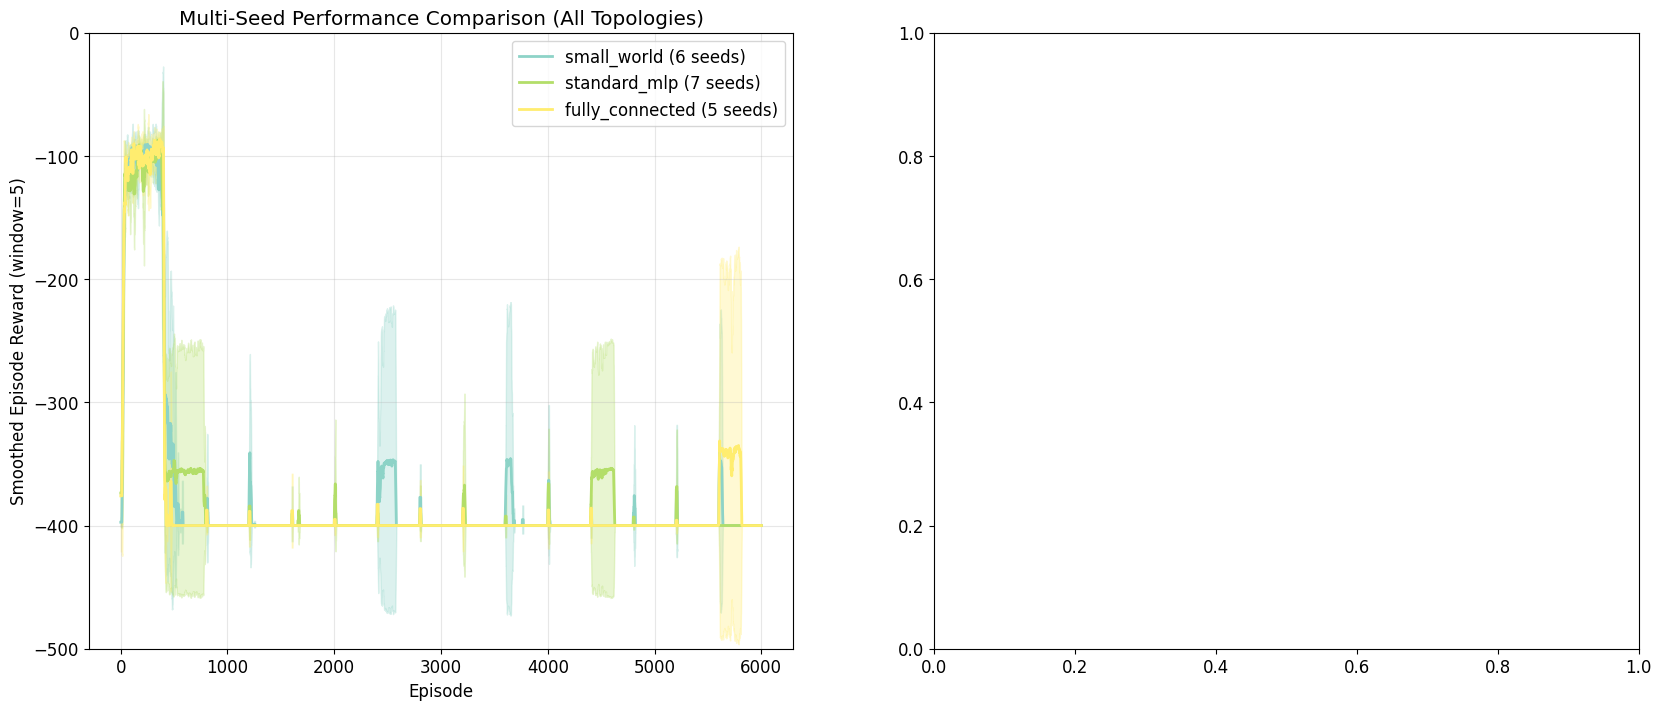

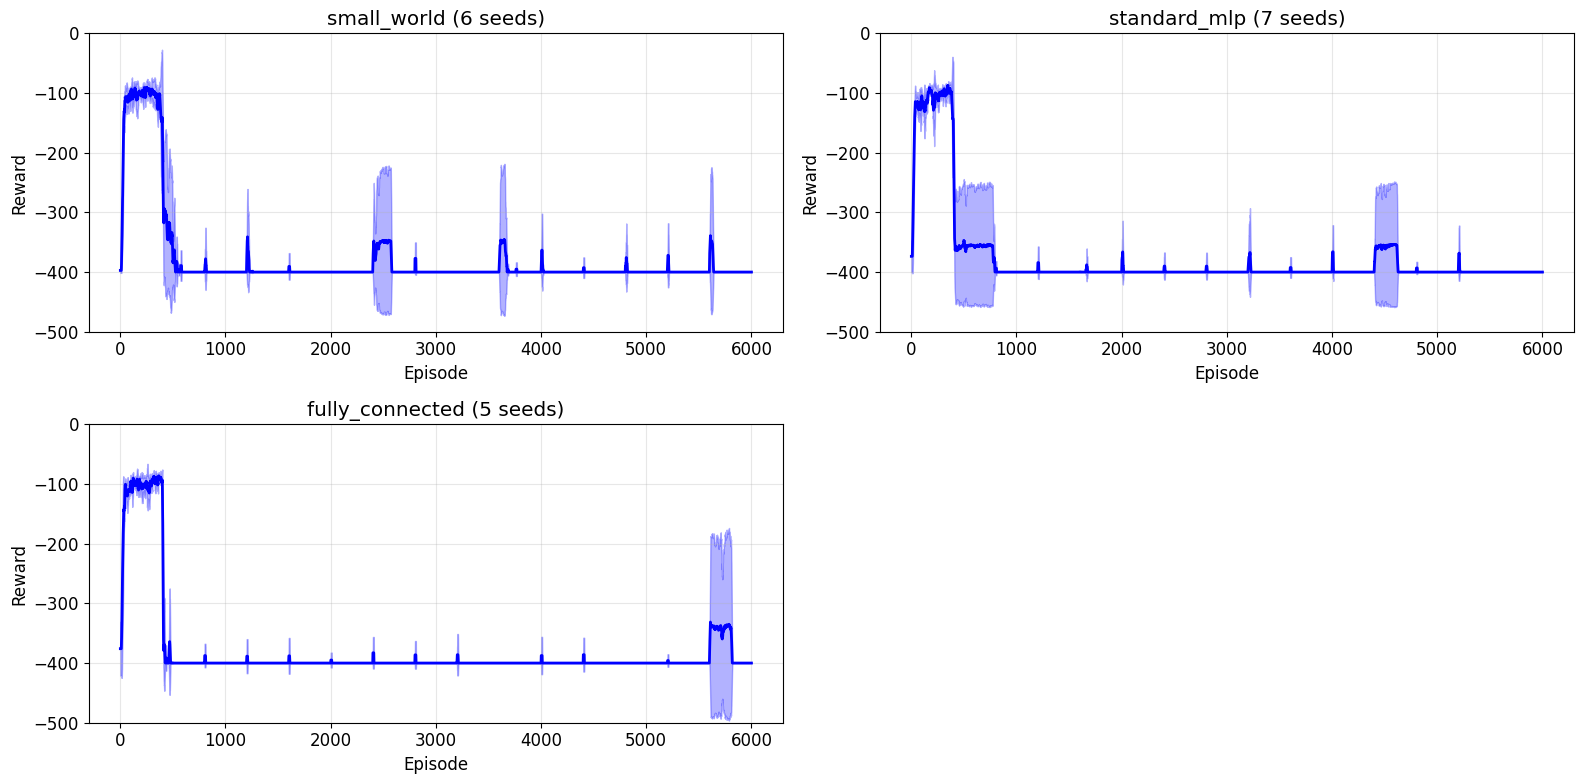

✅ Figure6 aggregation plots generated


In [58]:
def plot_figure6_aggregation(figure6_data: Dict):
    """
    Create Figure6-style plots with multi-seed aggregation and confidence intervals.
    """
    if not figure6_data:
        print("❌ No Figure6 data available")
        return
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: All topologies together
    ax1 = axes[0]
    colors = plt.cm.Set3(np.linspace(0, 1, len(figure6_data)))
    
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        episodes = data['episodes']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        # Plot mean line
        ax1.plot(episodes, mean_rewards, 
                label=f"{data['topology_type']} ({data['num_seeds']} seeds)", 
                color=colors[i], linewidth=2)
        
        # Plot confidence interval
        ax1.fill_between(episodes, lower_bound, upper_bound, 
                        alpha=0.3, color=colors[i])
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Smoothed Episode Reward (window=5)')
    ax1.set_title('Multi-Seed Performance Comparison (All Topologies)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-500, 0)  # Set y-axis limits to [0, 500]
    
    # Plot 2: Individual topology plots
    ax2 = axes[1]
    n_topologies = len(figure6_data)
    cols = 2
    rows = (n_topologies + 1) // 2
    
    # Create subplot grid
    fig2, axes2 = plt.subplots(rows, cols, figsize=(16, 4*rows))
    if rows == 1:
        axes2 = axes2.reshape(1, -1)
    
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        row = i // cols
        col = i % cols
        ax = axes2[row, col]
        
        episodes = data['episodes']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        ax.plot(episodes, mean_rewards, linewidth=2, color='blue')
        ax.fill_between(episodes, lower_bound, upper_bound, alpha=0.3, color='blue')
        
        ax.set_xlabel('Episode')
        ax.set_ylabel('Reward')
        ax.set_title(f"{data['topology_type']} ({data['num_seeds']} seeds)")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-500, 0)  # Set y-axis limits to [0, 500]
    
    # Hide empty subplots
    for i in range(len(figure6_data), rows * cols):
        row = i // cols
        col = i % cols
        axes2[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Figure6 aggregation plots generated")

# Generate Figure6 plots
plot_figure6_aggregation(figure6_data)

## Section 2: Learning Speed Analysis (Option B)

Calculate and plot learning speed using sliding window derivatives of smoothed reward curves.

In [59]:
def calculate_learning_speed(figure6_data: Dict, derivative_window: int = 10) -> Dict:
    """
    Calculate learning speed using sliding window derivatives.
    
    Args:
        figure6_data: Data from Figure6 analysis
        derivative_window: Window size for derivative calculation
        
    Returns:
        Dictionary with learning speed data for each topology
    """
    learning_speed_data = {}
    
    for topology_key, data in figure6_data.items():
        episodes = data['episodes']
        mean_rewards = data['mean_rewards']
        
        if len(episodes) < derivative_window:
            continue
        
        # Calculate sliding window derivative
        learning_rates = []
        derivative_episodes = []
        
        for i in range(derivative_window, len(episodes)):
            # Calculate rate of change over the window
            window_start = i - derivative_window
            window_end = i
            
            reward_change = mean_rewards[window_end] - mean_rewards[window_start]
            episode_change = episodes[window_end] - episodes[window_start]
            
            if episode_change > 0:
                learning_rate = reward_change / episode_change
            else:
                learning_rate = 0
            
            learning_rates.append(learning_rate)
            derivative_episodes.append(episodes[i])
        
        learning_speed_data[topology_key] = {
            'episodes': derivative_episodes,
            'learning_rates': learning_rates,
            'topology_type': data['topology_type'],
            'task_name': data['task_name']
        }
    
    return learning_speed_data

# Calculate learning speed
print("🔄 Calculating learning speed...")
learning_speed_data = calculate_learning_speed(figure6_data)
print(f"✅ Calculated learning speed for {len(learning_speed_data)} topology types")

🔄 Calculating learning speed...
✅ Calculated learning speed for 3 topology types


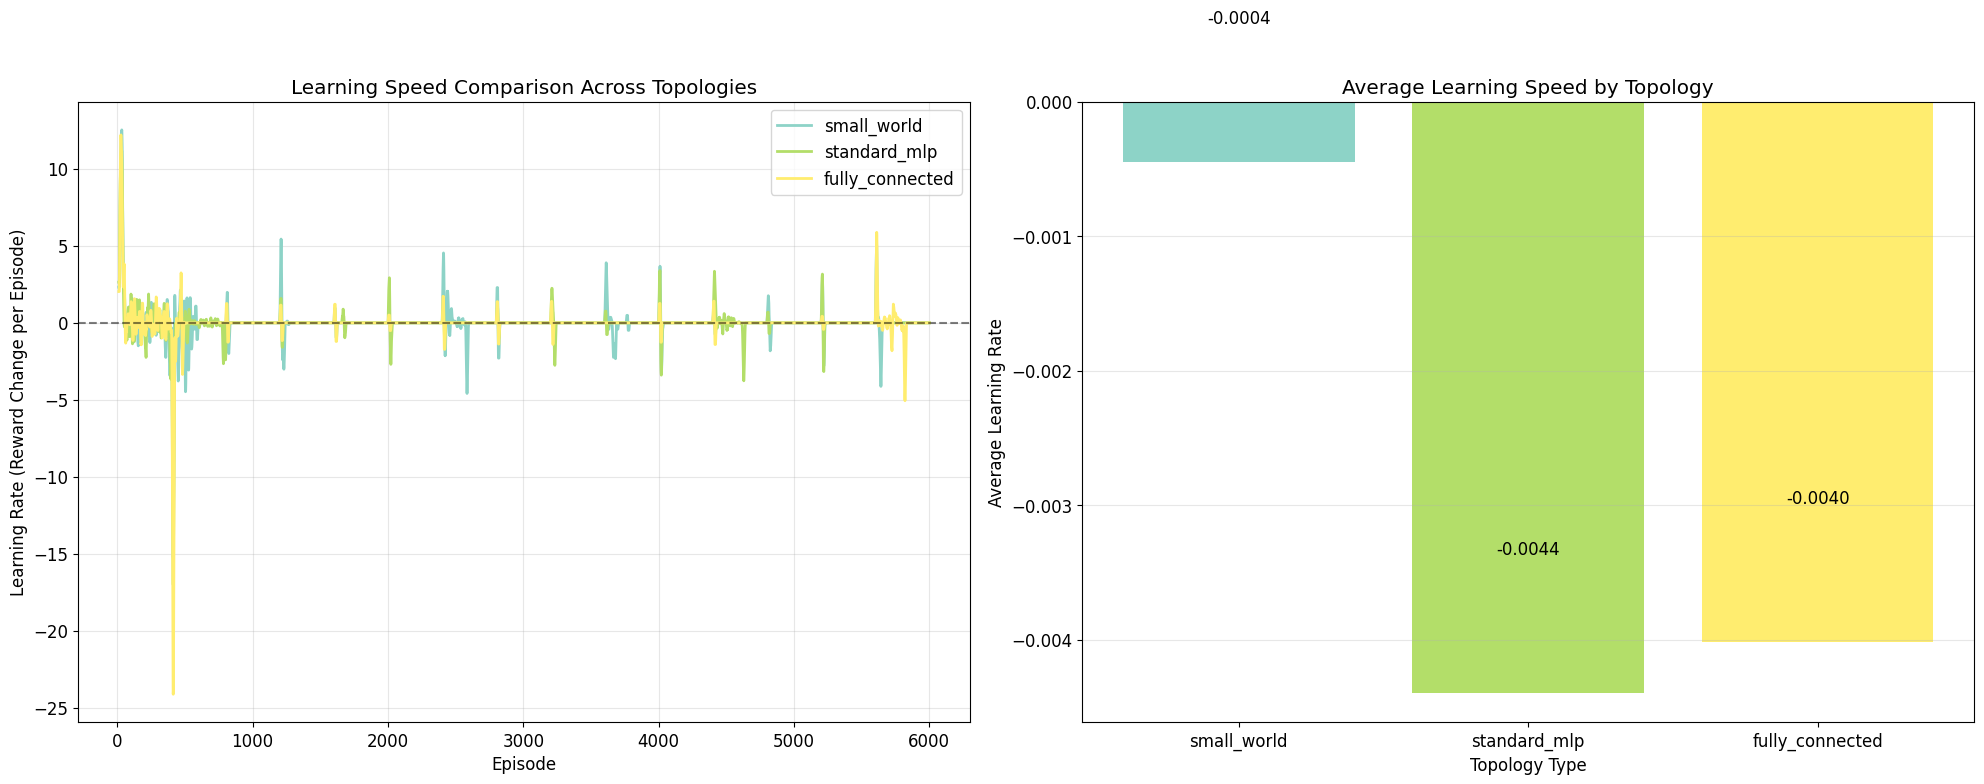

✅ Learning speed plots generated


In [60]:
def plot_learning_speed(learning_speed_data: Dict):
    """
    Plot learning speed comparison across topologies.
    """
    if not learning_speed_data:
        print("❌ No learning speed data available")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Learning rates over time
    colors = plt.cm.Set3(np.linspace(0, 1, len(learning_speed_data)))
    
    for i, (topology_key, data) in enumerate(learning_speed_data.items()):
        episodes = data['episodes']
        learning_rates = data['learning_rates']
        
        # Apply additional smoothing for better visualization
        smoothed_rates = apply_window_smoothing(learning_rates, window=5)
        
        ax1.plot(episodes, smoothed_rates, 
                label=f"{data['topology_type']}", 
                color=colors[i], linewidth=2)
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Learning Rate (Reward Change per Episode)')
    ax1.set_title('Learning Speed Comparison Across Topologies')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Plot 2: Average learning rates
    topology_names = []
    avg_learning_rates = []
    
    for topology_key, data in learning_speed_data.items():
        topology_names.append(data['topology_type'])
        avg_rate = np.mean(data['learning_rates'])
        avg_learning_rates.append(avg_rate)
    
    bars = ax2.bar(topology_names, avg_learning_rates, color=colors[:len(topology_names)])
    ax2.set_xlabel('Topology Type')
    ax2.set_ylabel('Average Learning Rate')
    
    ax2.set_title('Average Learning Speed by Topology')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, rate in zip(bars, avg_learning_rates):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{rate:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Learning speed plots generated")

# Generate learning speed plots
plot_learning_speed(learning_speed_data)

## Section 3: Cumulative Reward Table

Calculate cumulative sums of mean episode rewards (averaged across seeds) and display as a comparison table.

In [61]:
def calculate_cumulative_rewards(figure6_data: Dict) -> pd.DataFrame:
    """
    Calculate cumulative rewards for each topology and create comparison table.
    """
    cumulative_data = []
    
    for topology_key, data in figure6_data.items():
        episodes = data['episodes']
        mean_rewards = data['mean_rewards']
        
        # Calculate cumulative sum
        cumulative_rewards = np.cumsum(mean_rewards)
        
        # Store key milestones
        milestones = [100, 500, 1000, 2000, 3000, 4000, 5000, 6000]
        milestone_data = {}
        
        for milestone in milestones:
            if milestone <= len(episodes):
                idx = milestone - 1  # Convert to 0-based index
                milestone_data[f'episode_{milestone}'] = cumulative_rewards[idx]
            else:
                milestone_data[f'episode_{milestone}'] = np.nan
        
        # Add final cumulative reward
        final_cumulative = cumulative_rewards[-1]
        
        row_data = {
            'Topology': data['topology_type'],
            'Task': data['task_name'],
            'Seeds': data['num_seeds'],
            'Total Episodes': len(episodes),
            'Final Cumulative Reward': final_cumulative,
            **milestone_data
        }
        
        cumulative_data.append(row_data)
    
    # Create DataFrame
    df = pd.DataFrame(cumulative_data)
    
    # Reorder columns for better readability
    base_cols = ['Topology', 'Task', 'Seeds', 'Total Episodes', 'Final Cumulative Reward']
    milestone_cols = [col for col in df.columns if col.startswith('episode_')]
    milestone_cols.sort(key=lambda x: int(x.split('_')[1]))
    
    df = df[base_cols + milestone_cols]
    
    return df

# Calculate cumulative rewards
print("�� Calculating cumulative rewards...")
cumulative_df = calculate_cumulative_rewards(figure6_data)
print("✅ Cumulative rewards calculated")

�� Calculating cumulative rewards...
✅ Cumulative rewards calculated


In [62]:
def display_cumulative_table(cumulative_df: pd.DataFrame):
    """
    Display cumulative reward comparison table.
    """
    if cumulative_df.empty:
        print("❌ No cumulative data available")
        return
    
    print("📊 Cumulative Reward Comparison Table")
    print("=" * 80)
    
    # Format the DataFrame for display
    display_df = cumulative_df.copy()
    
    # Format numeric columns
    numeric_cols = display_df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col != 'Seeds' and col != 'Total Episodes':
            display_df[col] = display_df[col].round(2)
    
    # Display the table
    print(display_df.to_string(index=False))
    
    print("\n" + "=" * 80)
    print("📈 Key Insights:")
    
    # Find best performing topology
    if 'Final Cumulative Reward' in display_df.columns:
        best_topology = display_df.loc[display_df['Final Cumulative Reward'].idxmax()]
        print(f"🏆 Best Overall Performance: {best_topology['Topology']} "
              f"({best_topology['Final Cumulative Reward']:.2f} cumulative reward)")
    
    # Show topology rankings
    if 'Final Cumulative Reward' in display_df.columns:
        rankings = display_df.sort_values('Final Cumulative Reward', ascending=False)
        print("\n🏅 Topology Rankings (by Final Cumulative Reward):")
        for i, (_, row) in enumerate(rankings.iterrows()):
            print(f"   {i+1}. {row['Topology']}: {row['Final Cumulative Reward']:.2f}")
    
    print("\n✅ Cumulative reward analysis complete")

# Display cumulative reward table
display_cumulative_table(cumulative_df)

📊 Cumulative Reward Comparison Table
       Topology       Task  Seeds  Total Episodes  Final Cumulative Reward  episode_100  episode_500  episode_1000  episode_2000  episode_3000  episode_4000  episode_5000  episode_6000
    small_world Acrobot-v1      6            6000              -2264167.17    -17762.23    -80545.70    -279431.83    -678437.17   -1070055.00   -1466813.67   -1866048.67   -2264167.17
   standard_mlp Acrobot-v1      7            6000              -2259966.01    -17548.57    -84155.27    -271583.16    -671301.16   -1070762.87   -1470113.59   -1860282.44   -2259966.01
fully_connected Acrobot-v1      5            6000              -2270708.92    -17277.88    -84213.92    -284088.52    -683852.72   -1083492.92   -1483353.12   -1883086.52   -2270708.92

📈 Key Insights:
🏆 Best Overall Performance: standard_mlp (-2259966.01 cumulative reward)

🏅 Topology Rankings (by Final Cumulative Reward):
   1. standard_mlp: -2259966.01
   2. small_world: -2264167.17
   3. fully_connect